# Benchmarking `nvjpeg2k` 📊

# 📈 Data Visualization & Analysis

Now we will plot the collected data to understand the results. We will focus on:
1.  **Rate-Distortion:** How do quality metrics (like VMAF) change with file size?
2.  **Quality vs. File Size:** How does the `-quality` setting impact file size for different subsampling methods?
3.  **Encoding Performance:** Which DCT method is fastest? How does resolution affect encoding time?
4.  **Decoding Performance:** How does resolution affect decoding time?

In [1]:
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/s248508/Pictures/benchmark-result/nvjpeg2k_results_1280x720.csv")
df.head()

,img_name,subsampling,mode,quality,enc_avg_time_milliseconds,enc_avg_fps,enc_avg_mps,dec_avg_time_milliseconds,dec_avg_fps,dec_avg_mps,compressed_size_bytes,compression_ratio,bpp,psnr,ssim
0,r000da54ft.rgb,444,lossy,1,3.69,271.003,249.756098,2.66,375.940,346.466165,1252,2208.306709,0.010868,18.8504,0.514737
1,r000da54ft.rgb,444,lossy,10,7.25,137.931,127.117241,5.33,187.617,172.908068,18474,149.658980,0.160365,29.4829,0.885201
2,r000da54ft.rgb,444,lossy,20,9.16,109.170,100.611354,7.12,140.449,129.438202,35306,78.309636,0.306476,33.1651,0.939701
3,r000da54ft.rgb,444,lossy,30,10.21,97.943,90.264447,7.10,140.845,129.802817,50073,55.215386,0.434661,35.4151,0.959442
4,r000da54ft.rgb,444,lossy,40,11.07,90.334,83.252033,8.05,124.224,114.484472,63158,43.775927,0.548247,37.0247,0.969705


## Encoding Parameters vs. quality metrics

In [14]:
plt.style.use('default')


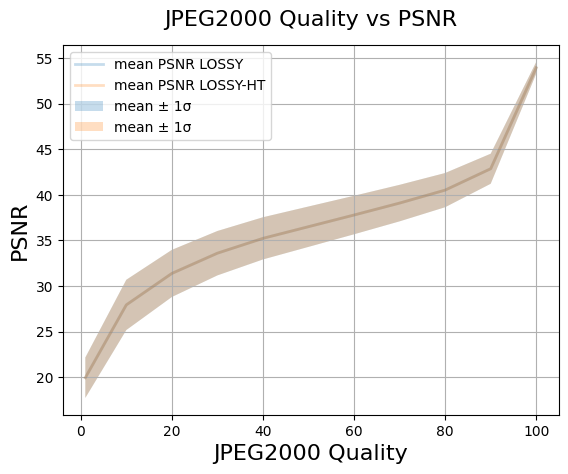

In [16]:
# Aggregate per quality across experiments
stats_lossy = (
    df[df["mode"] == "lossy"].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_lossy["quality"].to_numpy()
m_lossy = stats_lossy["mean"].to_numpy()
s_lossy = stats_lossy["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_lossy = np.nan_to_num(s_lossy, nan=0.0)

stats_lossyht = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)["psnr"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_lossyht = stats_lossyht["mean"].to_numpy()
s_lossyht = stats_lossyht["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_lossyht = np.nan_to_num(s_lossyht, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs PSNR", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("PSNR", fontsize=16)
ax.grid(True)

ax.plot(x, m_lossy, label="mean PSNR LOSSY", alpha=0.25, linewidth=2)
ax.plot(x, m_lossyht, label="mean PSNR LOSSY-HT", alpha=0.25, linewidth=2)
ax.fill_between(x, m_lossy - s_lossy, m_lossy + s_lossy, alpha=0.25, label="mean ± 1σ")
ax.fill_between(x, m_lossyht - s_lossyht, m_lossyht + s_lossyht, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

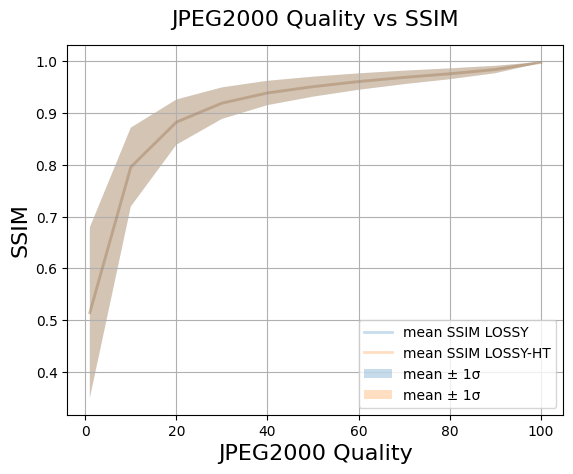

In [17]:
# Aggregate per quality across experiments
stats_lossy = (
    df[df["mode"] == "lossy"].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_lossy["quality"].to_numpy()
m_lossy = stats_lossy["mean"].to_numpy()
s_lossy = stats_lossy["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_lossy = np.nan_to_num(s_lossy, nan=0.0)

stats_lossyht = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)["ssim"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_lossyht = stats_lossyht["mean"].to_numpy()
s_lossyht = stats_lossyht["std"].to_numpy()

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_lossyht = np.nan_to_num(s_lossyht, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs SSIM", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("SSIM", fontsize=16)
ax.grid(True)

ax.plot(x, m_lossy, label="mean SSIM LOSSY", alpha=0.25, linewidth=2)
ax.plot(x, m_lossyht, label="mean SSIM LOSSY-HT", alpha=0.25, linewidth=2)
ax.fill_between(x, m_lossy - s_lossy, m_lossy + s_lossy, alpha=0.25, label="mean ± 1σ")
ax.fill_between(x, m_lossyht - s_lossyht, m_lossyht + s_lossyht, alpha=0.25, label="mean ± 1σ")

ax.legend()
plt.show()

## Encoding Parameters vs. File Size


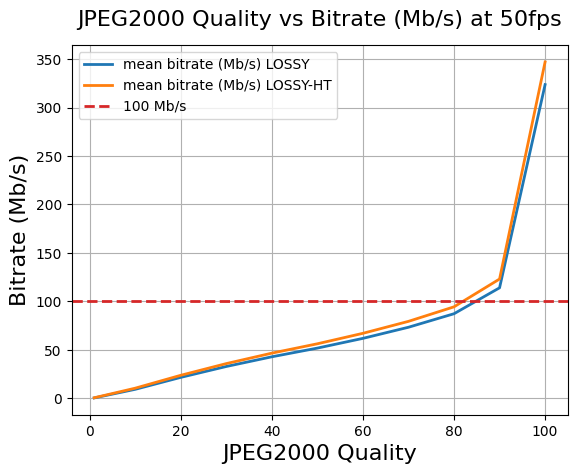

In [20]:
# Aggregate per quality across experiments
stats_lossy = (
    df[df["mode"] == "lossy"].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_lossy["quality"].to_numpy()
m_lossy = stats_lossy["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_lossy = stats_lossy["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_lossy = np.nan_to_num(s_lossy, nan=0.0)

stats_lossyht = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)["compressed_size_bytes"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_lossyht = stats_lossyht["mean"].to_numpy()  * 50 * 8 / 1_000_000
s_lossyht = stats_lossyht["std"].to_numpy()  * 50 * 8 / 1_000_000

# Handle edge case: std is NaN when only 1 sample exists at a quality
s_lossyht = np.nan_to_num(s_lossyht, nan=0.0)

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs Bitrate (Mb/s) at 50fps", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("Bitrate (Mb/s)", fontsize=16)
ax.grid(True)

ax.plot(x, m_lossy, label="mean bitrate (Mb/s) LOSSY", linewidth=2)
ax.plot(x, m_lossyht, label="mean bitrate (Mb/s) LOSSY-HT", linewidth=2)

# --- Household connection reference lines ---
ax.axhline(100, color="tab:red",   linestyle="--", linewidth=2, label="100 Mb/s")

ax.legend()
plt.show()

We can observe an explosion in file size from quality 95 onwards, and a sharp increase from quality 90 onwards.

## Encoding Parameters vs. Performance

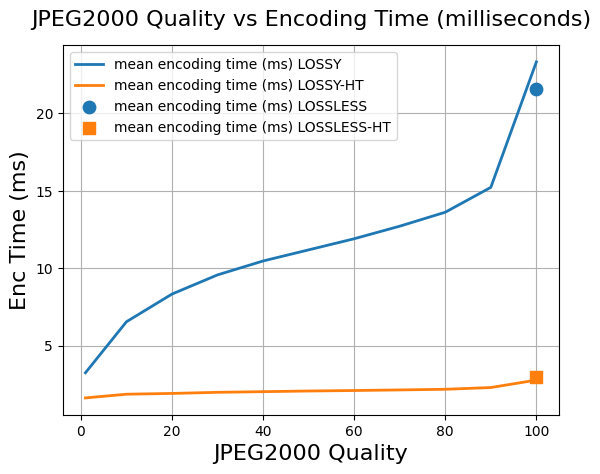

In [37]:
# Aggregate per quality across experiments
stats_lossy = (
    df[df["mode"] == "lossy"].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_lossy["quality"].to_numpy()
m_lossy = stats_lossy["mean"].to_numpy()

stats_lossless = (
    df[df["mode"] == "lossless"]["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std"))

m_lossless = stats_lossless["mean"]

stats_lossyht = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_lossyht = stats_lossyht["mean"].to_numpy()

stats_losslessht = (
    df[df["mode"] == "lossless-ht"]["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
)

m_losslessht = stats_losslessht["mean"]

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_lossy, label="mean encoding time (ms) LOSSY", linewidth=2)
ax.plot(x, m_lossyht, label="mean encoding time (ms) LOSSY-HT", linewidth=2)

ax.scatter([100], [m_lossless],
           label="mean encoding time (ms) LOSSLESS",
           s=80, marker="o", zorder=5)

ax.scatter([100], [m_losslessht],
           label="mean encoding time (ms) LOSSLESS-HT",
           s=80, marker="s", zorder=5)

ax.legend()
plt.show()

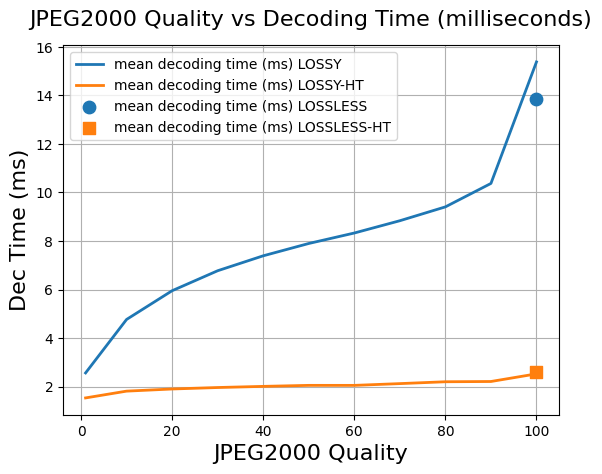

In [40]:
# Aggregate per quality across experiments
stats_lossy = (
    df[df["mode"] == "lossy"].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

x = stats_lossy["quality"].to_numpy()
m_lossy = stats_lossy["mean"].to_numpy()

stats_lossless = (
    df[df["mode"] == "lossless"]["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std"))

m_lossless = stats_lossless["mean"]

stats_lossyht = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_lossyht = stats_lossyht["mean"].to_numpy()

stats_losslessht = (
    df[df["mode"] == "lossless-ht"]["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
)

m_losslessht = stats_losslessht["mean"]

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_lossy, label="mean decoding time (ms) LOSSY", linewidth=2)
ax.plot(x, m_lossyht, label="mean decoding time (ms) LOSSY-HT", linewidth=2)

ax.scatter([100], [m_lossless],
           label="mean decoding time (ms) LOSSLESS",
           s=80, marker="o", zorder=5)

ax.scatter([100], [m_losslessht],
           label="mean decoding time (ms) LOSSLESS-HT",
           s=80, marker="s", zorder=5)

ax.legend()
plt.show()

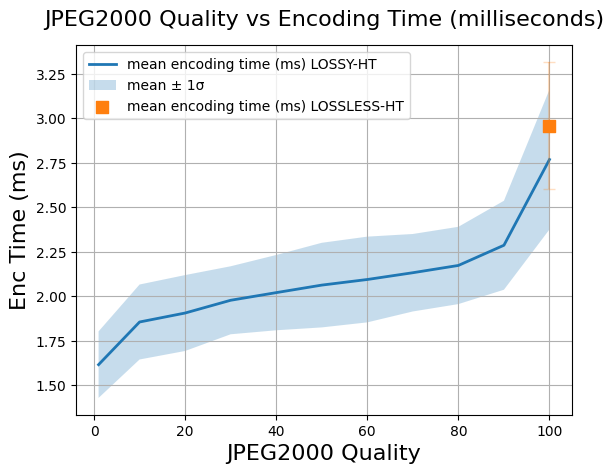

In [44]:
# Aggregate per quality across experiments
stats_lossyht = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_lossyht = stats_lossyht["mean"].to_numpy()
s_lossyht = stats_lossyht["std"].to_numpy()

stats_losslessht = (
    df[df["mode"] == "lossless-ht"]["enc_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
)

m_losslessht = stats_losslessht["mean"]

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs Encoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("Enc Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_lossyht, label="mean encoding time (ms) LOSSY-HT", linewidth=2)
ax.fill_between(x, m_lossyht - s_lossyht, m_lossyht + s_lossyht, alpha=0.25, label="mean ± 1σ")

ax.scatter([100], [m_losslessht],
           label="mean encoding time (ms) LOSSLESS-HT",
           s=80, marker="s", zorder=5)

ax.errorbar([100], [m_losslessht],
            yerr=[stats_losslessht["std"]], alpha=0.25,
            fmt="s", capsize=4)


ax.legend()
plt.show()

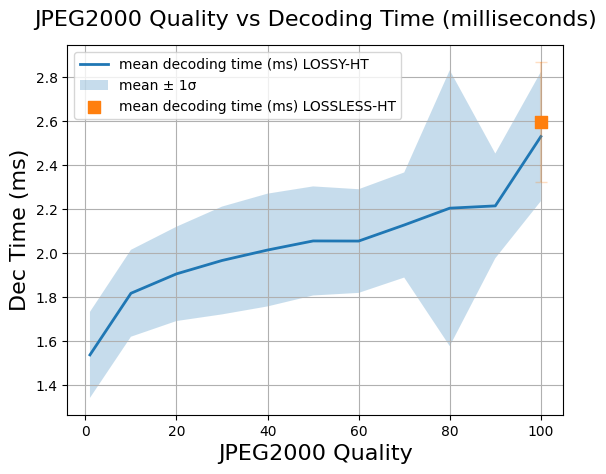

In [45]:
# Aggregate per quality across experiments
stats_lossyht = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
      .sort_values("quality")
)

m_lossyht = stats_lossyht["mean"].to_numpy()
s_lossyht = stats_lossyht["std"].to_numpy()

stats_losslessht = (
    df[df["mode"] == "lossless-ht"]["dec_avg_time_milliseconds"]
      .agg(mean="mean", std="std")
)

m_losslessht = stats_losslessht["mean"]

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs Decoding Time (milliseconds)", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("Dec Time (ms)", fontsize=16)
ax.grid(True)

ax.plot(x, m_lossyht, label="mean decoding time (ms) LOSSY-HT", linewidth=2)
ax.fill_between(x, m_lossyht - s_lossyht, m_lossyht + s_lossyht, alpha=0.25, label="mean ± 1σ")

ax.scatter([100], [m_losslessht],
           label="mean decoding time (ms) LOSSLESS-HT",
           s=80, marker="s", zorder=5)

ax.errorbar([100], [m_losslessht],
            yerr=[stats_losslessht["std"]], alpha=0.25,
            fmt="s", capsize=4)


ax.legend()
plt.show()

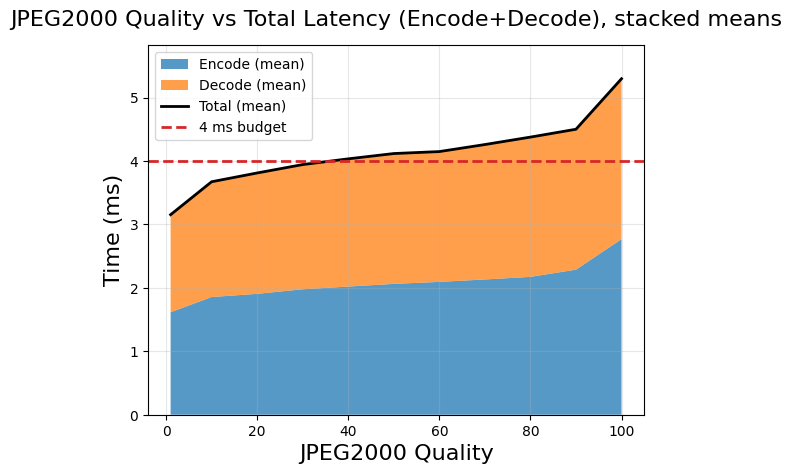

In [47]:
# Aggregate both metrics per quality (means + stds, in case you want them later)
stats = (
    df[df["mode"] == "lossy-ht"].groupby("quality", as_index=False)
      .agg(enc_mean=("enc_avg_time_milliseconds", "mean"),
           enc_std =("enc_avg_time_milliseconds", "std"),
           dec_mean=("dec_avg_time_milliseconds", "mean"),
           dec_std =("dec_avg_time_milliseconds", "std"))
      .sort_values("quality")
)

q   = stats["quality"].to_numpy()
enc = stats["enc_mean"].to_numpy()
dec = stats["dec_mean"].to_numpy()

total = enc + dec

fig, ax = plt.subplots()
ax.set_title("JPEG2000 Quality vs Total Latency (Encode+Decode), stacked means", y=1.03, fontsize=16)
ax.set_xlabel("JPEG2000 Quality", fontsize=16)
ax.set_ylabel("Time (ms)", fontsize=16)
ax.grid(True, alpha=0.3)

# Stacked mean areas
ax.stackplot(q, enc, dec, labels=["Encode (mean)", "Decode (mean)"], alpha=0.75)

# Total mean line (optional but usually useful)
ax.plot(q, total, color="black", linewidth=2, label="Total (mean)")

# 4 ms total latency budget
ax.axhline(4.0, color="tab:red", linestyle="--", linewidth=2, label="4 ms budget")

# Make sure budget line is visible
ax.set_ylim(bottom=0, top=max(total.max(), 4.0) * 1.1)

ax.legend(loc="upper left")
plt.show()